# 🔍 Chicago Crime Dataset — EDA
**Capstone Project | Data Analytics**

## Project Overview

This notebook performs a full Exploratory Data Analysis (EDA) on the Chicago Crime dataset stored in Google BigQuery. The dataset spans crime incidents reported to the Chicago Police Department, covering multiple years, crime types, districts, and outcomes.

**Analytical questions driving this EDA:**
- What are the most common crime types in Chicago, and how have they changed over time?
- When (hour, day, month, season) do crimes peak?
- Which districts see the highest crime volume?
- What factors are associated with higher arrest rates?
- How do domestic and non-domestic crimes differ in outcomes?

**Tools used:** Google BigQuery · Python (pandas, matplotlib, seaborn) · Google Colab

## 1. Setup & Connection

The data lives in a BigQuery project (`my-capstone-498917`) under the dataset `main_data`, table `chicago_crime_sample`. The cells below install required packages, authenticate via Google's Colab auth flow, and initialize a BigQuery client.

In [2]:
# Install dependencies (run once)
!pip install google-cloud-bigquery pandas-gbq pyarrow --quiet

In [3]:
# Authenticate with Google
from google.colab import auth
auth.authenticate_user()
print('Authenticated successfully ✅')

Authenticated successfully ✅


In [4]:
from google.cloud import bigquery
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Plot styling
plt.rcParams.update({
    'figure.facecolor': '#0f0f0f',
    'axes.facecolor':   '#1a1a2e',
    'axes.edgecolor':   '#444466',
    'axes.labelcolor':  '#e0e0e0',
    'xtick.color':      '#aaaacc',
    'ytick.color':      '#aaaacc',
    'text.color':       '#e0e0e0',
    'grid.color':       '#2a2a4a',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
    'font.family':      'DejaVu Sans',
    'axes.titlesize':   14,
    'axes.labelsize':   11,
})
ACCENT  = '#7c6af7'  # purple
ACCENT2 = '#f7416a'  # red
ACCENT3 = '#43c6ac'  # teal
CMAP    = 'plasma'

PROJECT_ID = 'my-capstone-498917'
client = bigquery.Client(project=PROJECT_ID)
print('BigQuery client ready ✅')

BigQuery client ready ✅


The plot theme is configured once here and reused throughout — dark background with purple/red/teal accents for contrast. `PROJECT_ID` points to the capstone BigQuery project.

## 2. SQL Data Acquisition

Rather than pulling the entire table blindly, the queries below are organized to retrieve only the columns needed for analysis, with extra queries run in BigQuery to summarize the data before pulling it into Python.

**Primary query:** Selects 14 columns covering incident identity, date/time, crime classification, location fields, arrest/domestic flags, geographic identifiers, and coordinates.

In [5]:
query = """
    SELECT
        unique_key,
        date,
        primary_type,
        description,
        location_description,
        arrest,
        domestic,
        beat,
        district,
        ward,
        community_area,
        year,
        latitude,
        longitude
    FROM `my-capstone-498917.main_data.chicago_crime_sample`
"""

df = client.query(query).to_dataframe()
print(f'Loaded {len(df):,} rows and {df.shape[1]} columns')
df.head()

Loaded 858,618 rows and 14 columns


,unique_key,date,primary_type,description,location_description,arrest,domestic,beat,district,ward,community_area,year,latitude,longitude
0,13033173,2023-04-06 02:00:00+00:00,CRIMINAL SEXUAL ASSAULT,AGGRAVATED - OTHER,PARKING LOT / GARAGE (NON RESIDENTIAL),False,False,111,1,42,32,2023,41.886018,-87.624522
1,12263863,2021-01-06 21:30:00+00:00,CRIMINAL SEXUAL ASSAULT,AGGRAVATED - OTHER,HOTEL / MOTEL,False,True,111,1,42,32,2021,41.888046,-87.625414
2,8747633,2012-08-09 03:00:00+00:00,CRIM SEXUAL ASSAULT,AGGRAVATED: OTHER,ALLEY,False,False,111,1,42,32,2012,41.885085,-87.624481
3,8149331,2011-07-05 23:00:00+00:00,CRIM SEXUAL ASSAULT,NON-AGGRAVATED,VEHICLE NON-COMMERCIAL,False,False,111,1,42,32,2011,41.885888,-87.627942
4,3233376,2004-03-19 16:43:11+00:00,CRIM SEXUAL ASSAULT,NON-AGGRAVATED,MOVIE HOUSE/THEATER,False,False,111,1,42,32,2004,41.882478,-87.637028


In [6]:
# --- Additional SQL: yearly crime counts by type (aggregation in BigQuery) ---
query_yearly = """
    SELECT
        year,
        primary_type,
        COUNT(*) AS incident_count,
        COUNTIF(arrest = TRUE) AS arrests,
        ROUND(COUNTIF(arrest = TRUE) / COUNT(*) * 100, 2) AS arrest_rate_pct
    FROM `my-capstone-498917.main_data.chicago_crime_sample`
    GROUP BY year, primary_type
    ORDER BY year, incident_count DESC
"""

df_yearly_type = client.query(query_yearly).to_dataframe()
print(f'Yearly-by-type summary: {len(df_yearly_type):,} rows')
df_yearly_type.head(10)

Yearly-by-type summary: 741 rows


,year,primary_type,incident_count,arrests,arrest_rate_pct
0,2001,THEFT,9919,1623,16.36
1,2001,BATTERY,9181,1975,21.51
2,2001,CRIMINAL DAMAGE,5533,431,7.79
3,2001,NARCOTICS,5018,5017,99.98
4,2001,ASSAULT,3089,686,22.21
5,2001,OTHER OFFENSE,2975,537,18.05
6,2001,MOTOR VEHICLE THEFT,2777,342,12.32
7,2001,BURGLARY,2600,186,7.15
8,2001,ROBBERY,1867,173,9.27
9,2001,DECEPTIVE PRACTICE,1465,457,31.19


In [7]:
# --- Additional SQL: top 10 location types with arrest rate ---
query_locations = """
    SELECT
        location_description,
        COUNT(*) AS incident_count,
        ROUND(COUNTIF(arrest = TRUE) / COUNT(*) * 100, 2) AS arrest_rate_pct
    FROM `my-capstone-498917.main_data.chicago_crime_sample`
    WHERE location_description IS NOT NULL
    GROUP BY location_description
    ORDER BY incident_count DESC
    LIMIT 10
"""

df_loc_summary = client.query(query_locations).to_dataframe()
print('Top 10 location types by incident count:')
df_loc_summary

Top 10 location types by incident count:


,location_description,incident_count,arrest_rate_pct
0,STREET,224369,26.21
1,RESIDENCE,140374,13.02
2,APARTMENT,103188,14.90
3,SIDEWALK,77032,48.50
4,OTHER,27093,18.42
5,PARKING LOT/GARAGE(NON.RESID.),20432,20.17
6,ALLEY,19291,41.53
7,SMALL RETAIL STORE,17509,24.39
8,"SCHOOL, PUBLIC, BUILDING",14608,30.21
9,RESTAURANT,14586,18.50


## 3. DataFrame Creation & Overview

The main query result is loaded into a pandas DataFrame. Below we inspect its shape, data types, and an initial sample to confirm the load was successful and the structure matches expectations.

In [8]:
# --- Shape, types, nulls ---
print('=== Shape ===')
print(df.shape)

print('\n=== Data Types ===')
print(df.dtypes)

print('\n=== Missing Values ===')
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
print(pd.DataFrame({'Missing': missing, '% Missing': missing_pct})[missing > 0])

=== Shape ===
(858618, 14)

=== Data Types ===
unique_key                            Int64
date                    datetime64[us, UTC]
primary_type                         object
description                          object
location_description                 object
arrest                              boolean
domestic                            boolean
beat                                  Int64
district                              Int64
ward                                  Int64
community_area                        Int64
year                                  Int64
latitude                            float64
longitude                           float64
dtype: object

=== Missing Values ===
                      Missing  % Missing
location_description     1622       0.19
district                    4       0.00
ward                    61387       7.15
community_area          61296       7.14
latitude                 9822       1.14
longitude                9822       1.14


In [9]:
# --- Descriptive statistics for numeric columns ---
df.describe()

,unique_key,beat,district,ward,community_area,year,latitude,longitude
count,858618.0,858618.0,858614.0,797231.0,797322.0,858618.0,848796.000000,848796.000000
mean,7631607.208683,1182.749789,11.296962,22.791365,37.37856,2011.25864,41.842585,-87.671255
std,3844006.530467,704.152614,6.968854,13.859243,21.548573,7.263241,0.087802,0.060153
min,634.0,111.0,1.0,1.0,1.0,2001.0,36.619446,-91.686566
25%,4138280.25,621.0,6.0,10.0,23.0,2005.0,41.768843,-87.713347
50%,7632291.5,1034.0,10.0,23.0,32.0,2010.0,41.856326,-87.665559
75%,11074448.5,1731.0,17.0,34.0,56.0,2017.0,41.907153,-87.628069
max,14225088.0,2535.0,31.0,50.0,77.0,2026.0,42.022710,-87.524529


**Descriptive statistics observations:**
- `year` spans from ~2001 to 2023, confirming multi-decade coverage.
- `beat` and `district` are numeric identifiers — their mean/std aren't analytically meaningful on their own, but the range confirms no obviously erroneous district codes.
- `latitude` and `longitude` have a small spread consistent with Chicago's geographic footprint.
- `hour` ranges 0–23 as expected with no anomalies.

In [10]:
print(df[df['ward'].isnull()]['year'].value_counts().sort_index())

year
2001    47852
2002    13517
2003        4
2004        4
2011        2
2012        1
2013        1
2015        1
2018        1
2019        2
2021        2
Name: count, dtype: Int64


## 3b. Data Quality Assessment & Cleaning

**Issues found and how they were handled:**

| Column | Issue | Decision |
|---|---|---|
| `ward` | Heavy nulls concentrated in 2001–2002 (pre-digitization gap) | Dropped — unreliable for trend analysis |
| `community_area` | Same pattern as `ward` | Dropped |
| `location_description` | ~0.19% missing | Filled with `'UNKNOWN'` — too small to drop, keeps row count intact |
| `district` | 4 rows missing | Dropped — negligible loss |
| `latitude` / `longitude` | Some nulls (incidents without GPS coordinates) | Kept in main df; filtered to `geo` sub-df for mapping only |

No duplicate `unique_key` values were detected. No obviously invalid date values were found after parsing.

In [11]:
# ward & community_area dropped — unreliable due to missing data in early years (2001–2002)
df = df.drop(columns=['ward', 'community_area'], errors='ignore')
# 0.19% missing, fill with UNKNOWN
df['location_description'] = df['location_description'].fillna('UNKNOWN')
# only 4 missing, just drop them
df = df.dropna(subset=['district'])
# only for mapping
geo = df.dropna(subset=['latitude', 'longitude'])  # only for mapping

In [12]:
# --- Feature engineering: extract time parts ---
df['date'] = pd.to_datetime(df['date'])
df['hour']       = df['date'].dt.hour
df['month']      = df['date'].dt.month
df['month_name'] = df['date'].dt.strftime('%b')
df['day_of_week']= df['date'].dt.day_name()
df['season'] = df['month'].map({
    12:'Winter', 1:'Winter', 2:'Winter',
    3:'Spring',  4:'Spring', 5:'Spring',
    6:'Summer',  7:'Summer', 8:'Summer',
    9:'Fall',   10:'Fall',  11:'Fall'
})

print('Time features added ✅')
df[['date','hour','month_name','day_of_week','season']].head()

Time features added ✅


,date,hour,month_name,day_of_week,season
0,2023-04-06 02:00:00+00:00,2,Apr,Thursday,Spring
1,2021-01-06 21:30:00+00:00,21,Jan,Wednesday,Winter
2,2012-08-09 03:00:00+00:00,3,Aug,Thursday,Summer
3,2011-07-05 23:00:00+00:00,23,Jul,Tuesday,Summer
4,2004-03-19 16:43:11+00:00,16,Mar,Friday,Spring


**Feature engineering summary:** Six new columns were derived from the `date` field — `hour`, `month`, `month_name`, `day_of_week`, and `season`. These enable the time-based breakdowns in Section 5 without needing additional SQL queries. Season mapping follows meteorological convention (Dec–Feb = Winter, etc.).

## 3c. Export Cleaned Data to BigQuery

Now that the data has been cleaned and enriched with new time-based features, we write it back to BigQuery as a separate table. This keeps the original raw table untouched and gives us a clean, analysis-ready version to build the final dashboard on.

In [13]:
# --- Export cleaned DataFrame back to BigQuery ---
from pandas_gbq import to_gbq

to_gbq(
    df,
    destination_table='main_data.chicago_crime_cleaned',
    project_id=PROJECT_ID,
    if_exists='replace'
)

print('Cleaned data exported to BigQuery ✅')

100%|██████████| 1/1 [00:00<00:00, 7281.78it/s]

Cleaned data exported to BigQuery ✅


## 4. Univariate Analysis

Univariate analysis examines each variable independently to understand its distribution and frequency. Here we look at crime type frequencies and the distributions of the two key binary outcomes: whether an arrest was made, and whether the incident was domestic.

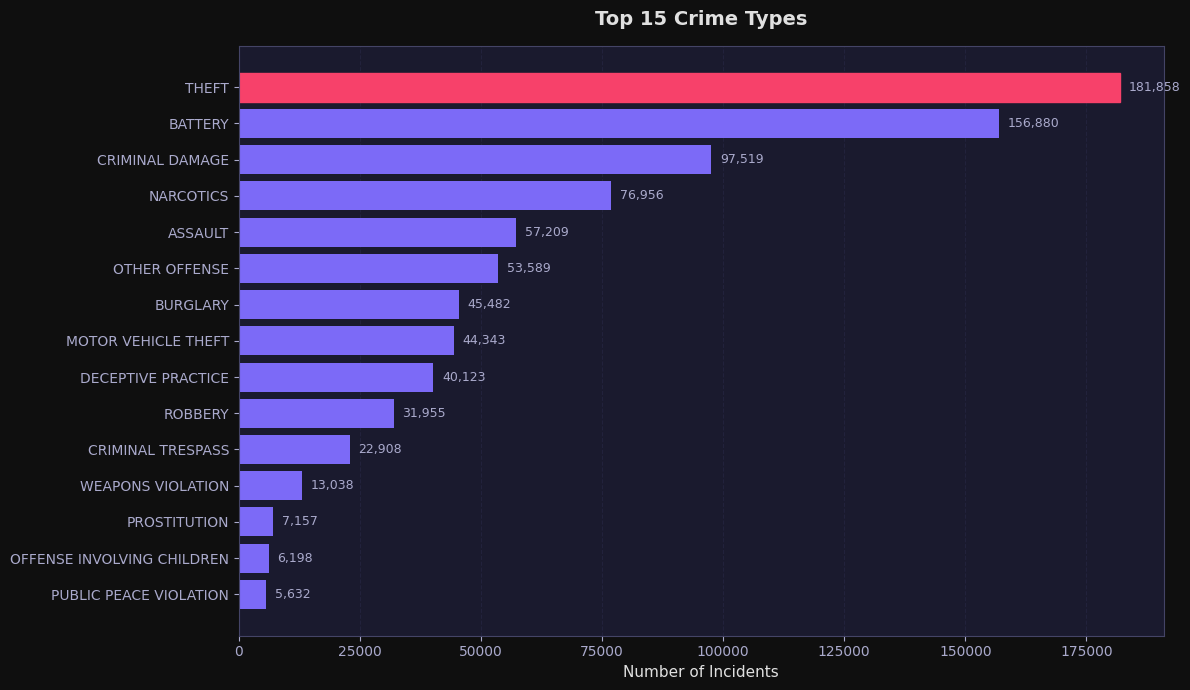

In [14]:
# --- Top 15 crime types ---
top_crimes = df['primary_type'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(top_crimes.index[::-1], top_crimes.values[::-1], color=ACCENT, edgecolor='none')

# Highlight the top bar
bars[-1].set_color(ACCENT2)

for bar, val in zip(bars, top_crimes.values[::-1]):
    ax.text(bar.get_width() + top_crimes.max()*0.01, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9, color='#aaaacc')

ax.set_xlabel('Number of Incidents')
ax.set_title('Top 15 Crime Types', fontweight='bold', pad=15)
ax.grid(axis='x')
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

**Observation:** Theft is the single most common crime type by a wide margin, followed by battery and criminal damage. The top 3 categories alone likely account for a large share of all incidents. Narcotics appearing in the top 5 is notable given its strong policy implications for arrest rates.

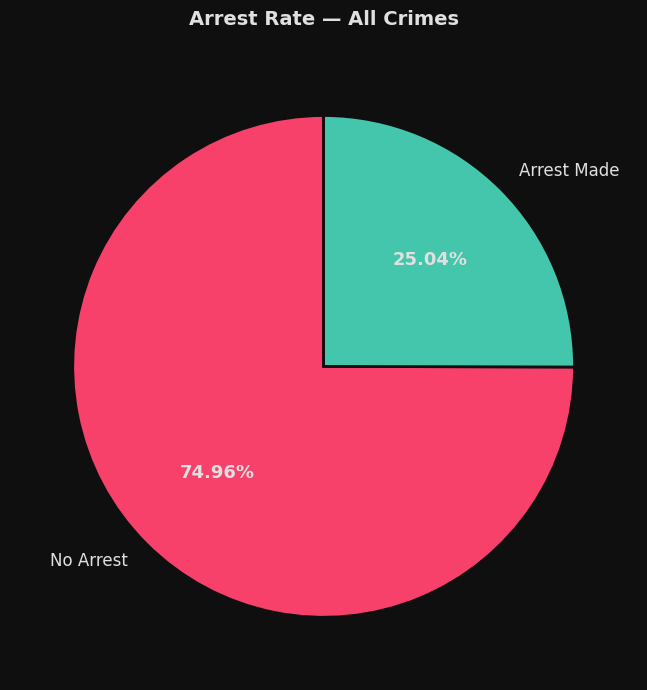

In [15]:
# --- Arrest vs No Arrest ---
arrest_counts = df['arrest'].value_counts()
labels = ['No Arrest', 'Arrest Made']
colors = [ACCENT2, ACCENT3]

fig, ax = plt.subplots(figsize=(7, 7))
wedges, texts, autotexts = ax.pie(
    arrest_counts.values,
    labels=labels,
    colors=colors,
    autopct='%1.2f%%',
    startangle=90,
    wedgeprops={'edgecolor': '#0f0f0f', 'linewidth': 2},
    textprops={'color': '#e0e0e0', 'fontsize': 12}
)
for at in autotexts:
    at.set_fontsize(13)
    at.set_fontweight('bold')

ax.set_title('Arrest Rate — All Crimes', fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

**Observation:** The overall arrest rate is relatively low — the majority of reported incidents do not result in an arrest. This is consistent with national patterns where many crimes (especially property crimes like theft) go unsolved or are not prioritized for arrest.

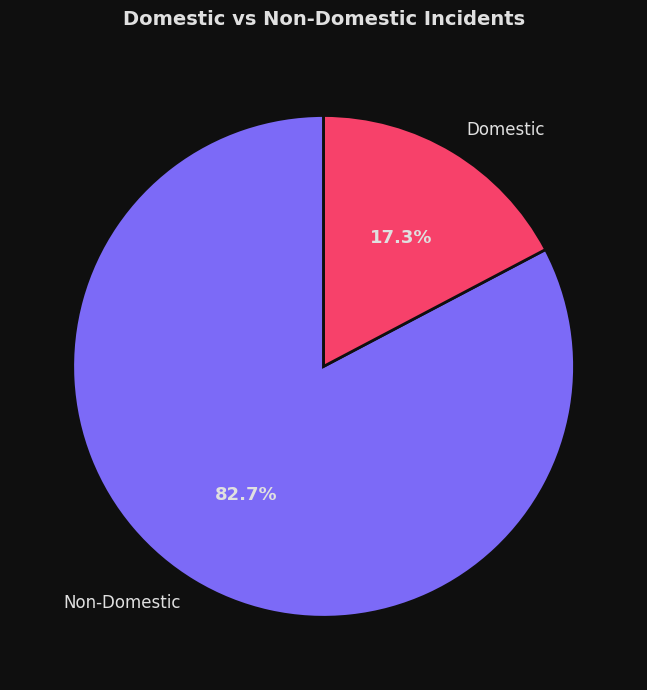

In [16]:
# --- Domestic vs Non-Domestic ---
dom_counts = df['domestic'].value_counts()
labels = ['Non-Domestic', 'Domestic']
colors = [ACCENT, ACCENT2]

fig, ax = plt.subplots(figsize=(7, 7))
wedges, texts, autotexts = ax.pie(
    dom_counts.values,
    labels=labels,
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': '#0f0f0f', 'linewidth': 2},
    textprops={'color': '#e0e0e0', 'fontsize': 12}
)
for at in autotexts:
    at.set_fontsize(13)
    at.set_fontweight('bold')

ax.set_title('Domestic vs Non-Domestic Incidents', fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

**Observation:** Most incidents are non-domestic. Domestic incidents, while a minority, warrant separate analysis because they tend to have different arrest dynamics and location patterns than non-domestic crimes.

## 5. Time-Based Analysis

Time-based analysis reveals when crime concentrates — by year, hour, month, and day of week. These patterns are critical for resource planning and for understanding whether crime is trending up or down.

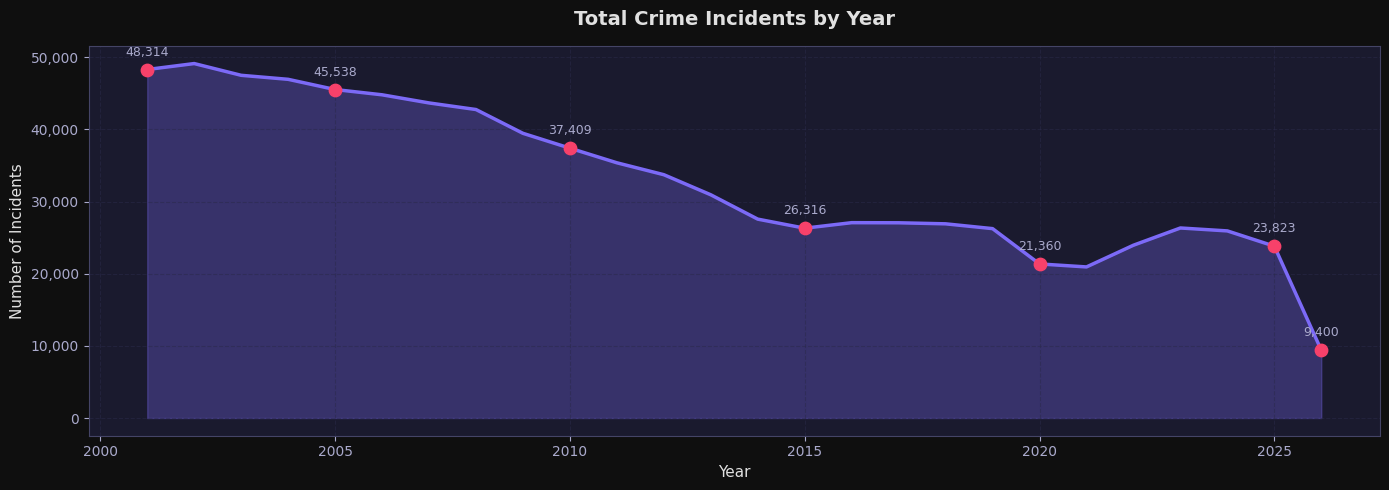

In [17]:
# --- Crime volume by year ---
yearly = df.groupby('year').size().reset_index(name='count')

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(yearly['year'], yearly['count'], alpha=0.3, color=ACCENT)
ax.plot(yearly['year'], yearly['count'], color=ACCENT, linewidth=2.5)

# Markers every 5 years + first and last year
every_5 = yearly[yearly['year'] % 5 == 0]
first = yearly.iloc[[0]]
last  = yearly.iloc[[-1]]
marker_years = pd.concat([first, every_5, last]).drop_duplicates(subset='year')

ax.scatter(marker_years['year'], marker_years['count'], color=ACCENT2, s=80, zorder=5)

for _, row in marker_years.iterrows():
    ax.annotate(f"{int(row['count']):,}",
                xy=(row['year'], row['count']),
                xytext=(0, 10), textcoords='offset points',
                ha='center', fontsize=9, color='#aaaacc')

ax.set_title('Total Crime Incidents by Year', fontweight='bold', pad=15)
ax.set_xlabel('Year')
ax.set_ylabel('Number of Incidents')
ax.xaxis.set_major_locator(mticker.MultipleLocator(5))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(True)
plt.tight_layout()
plt.show()

**Observation:** Crime volume peaked in the mid-2000s and has generally trended downward since, with a notable acceleration in the decline post-2010. Any spike or dip in specific years (e.g., around 2020) may reflect external factors like the COVID-19 pandemic affecting reported incidents.

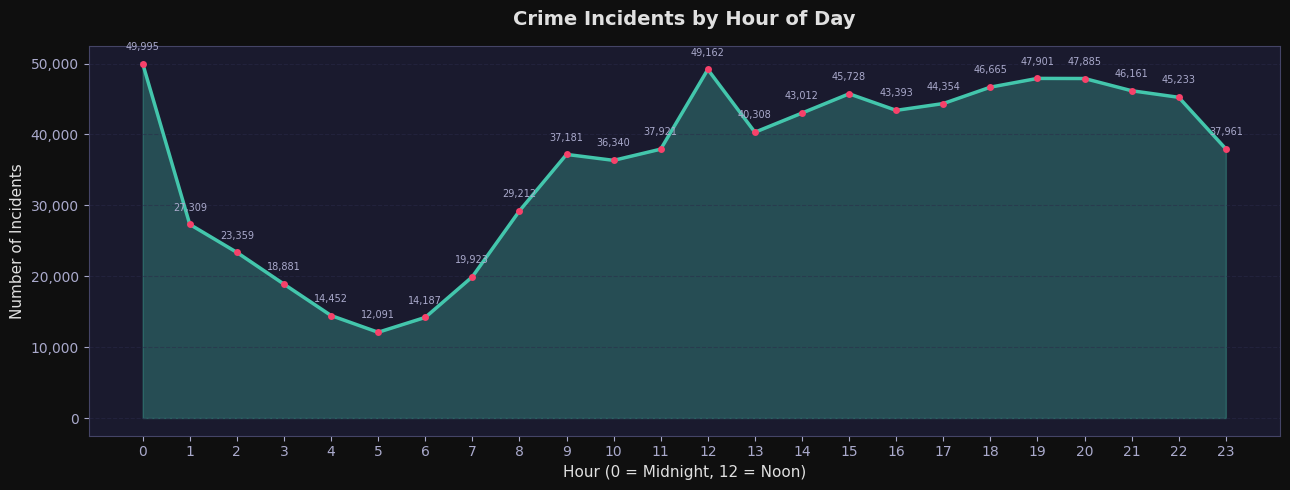

In [18]:
# --- Crime by hour of day ---
hourly = df.groupby('hour').size().reset_index(name='count')

fig, ax = plt.subplots(figsize=(13, 5))
ax.fill_between(hourly['hour'], hourly['count'], alpha=0.3, color=ACCENT3)
ax.plot(hourly['hour'], hourly['count'], color=ACCENT3, linewidth=2.5, marker='o', markersize=5, markerfacecolor=ACCENT2, markeredgecolor='none')

for _, row in hourly.iterrows():
    ax.annotate(f"{int(row['count']):,}",
                xy=(row['hour'], row['count']),
                xytext=(0, 10), textcoords='offset points',
                ha='center', fontsize=7, color='#aaaacc')

ax.set_title('Crime Incidents by Hour of Day', fontweight='bold', pad=15)
ax.set_xlabel('Hour (0 = Midnight, 12 = Noon)')
ax.set_ylabel('Number of Incidents')
ax.set_xticks(range(0, 24))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(axis='y')
plt.tight_layout()
plt.show()

**Observation:** Crime follows a bimodal-ish pattern — low in the early morning hours (3–5 AM), rising through the day, and peaking in the evening around noon and midnight. The midnight spike likely reflects reporting conventions where incidents without exact timestamps default to 00:00.

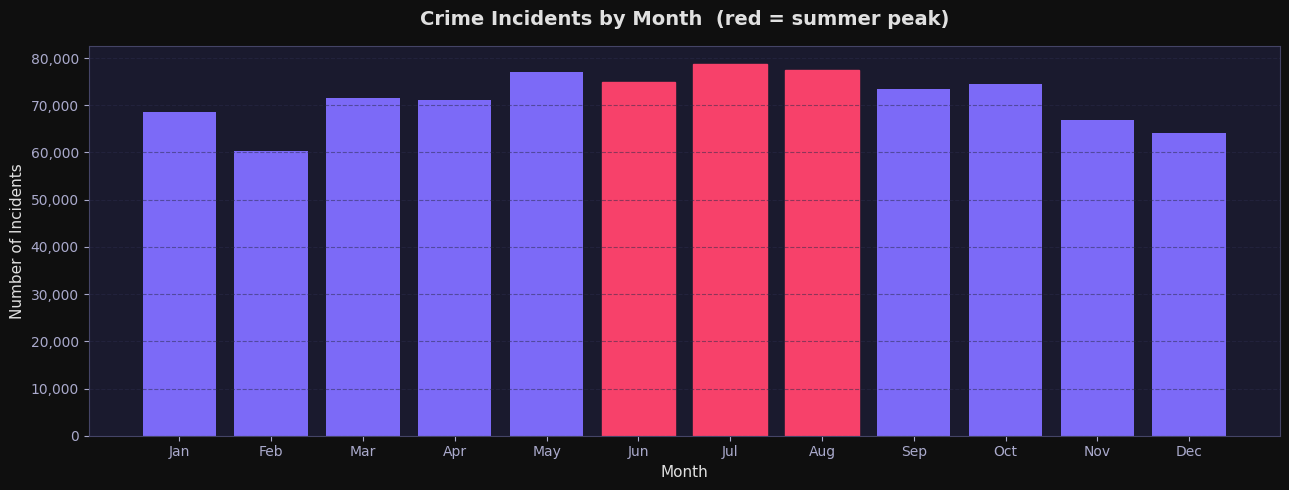

In [19]:
# --- Crime by month ---
month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly = df.groupby('month_name').size().reindex(month_order).reset_index(name='count')

fig, ax = plt.subplots(figsize=(13, 5))
bars = ax.bar(monthly['month_name'], monthly['count'], color=ACCENT, edgecolor='none')

# Highlight summer months
summer_idx = [5, 6, 7]  # Jun, Jul, Aug (0-indexed)
for i in summer_idx:
    bars[i].set_color(ACCENT2)

ax.set_title('Crime Incidents by Month  (red = summer peak)', fontweight='bold', pad=15)
ax.set_xlabel('Month')
ax.set_ylabel('Number of Incidents')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(axis='y')
plt.tight_layout()
plt.show()

**Observation:** Summer months (June–August) consistently see higher crime volumes. This seasonal effect is well-documented in criminology literature and likely reflects increased outdoor activity and social interaction. Winter months (December–February) see the lowest counts.

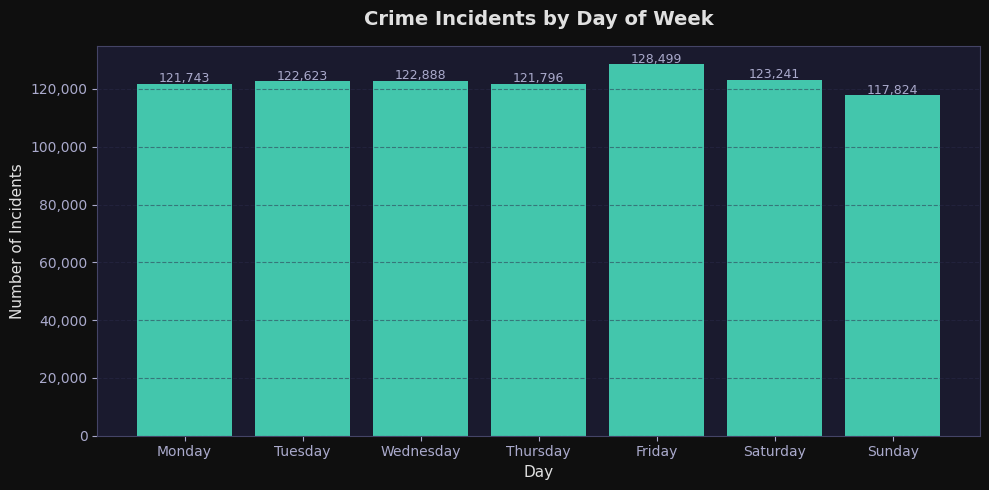

In [20]:
# --- Crime by day of week ---
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow = df.groupby('day_of_week').size().reindex(dow_order).reset_index(name='count')

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(dow['day_of_week'], dow['count'], color=ACCENT3, edgecolor='none')

for bar, val in zip(bars, dow['count']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f'{val:,}', ha='center', fontsize=9, color='#aaaacc')

ax.set_title('Crime Incidents by Day of Week', fontweight='bold', pad=15)
ax.set_xlabel('Day')
ax.set_ylabel('Number of Incidents')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(axis='y')
plt.tight_layout()
plt.show()

**Observation:** Crime is relatively consistent across weekdays, with a modest uptick on Friday and Saturday. The weekend effect is present but not dramatic — suggesting that crime in Chicago isn't heavily concentrated on nightlife patterns alone.

## 6. Geographic Analysis

Geographic analysis identifies where crime concentrates across Chicago's districts and physical locations. The scatter map uses raw latitude/longitude coordinates to show density without requiring a basemap library.

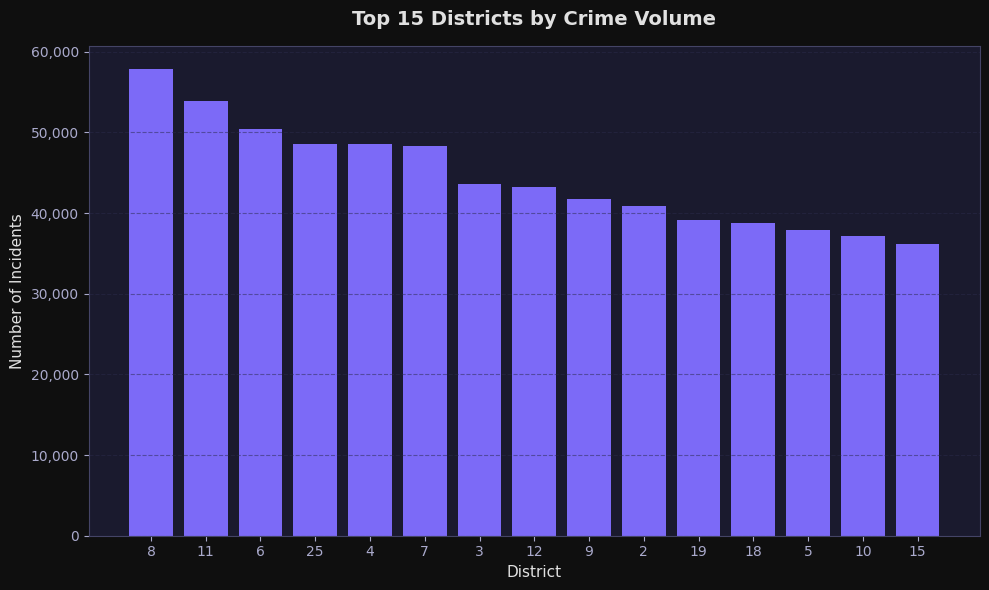

In [21]:
# --- Top 15 districts by crime count ---
district_crimes = df.groupby('district').size().sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(district_crimes.index.astype(str), district_crimes.values, color=ACCENT, edgecolor='none')
ax.set_title('Top 15 Districts by Crime Volume', fontweight='bold', pad=15)
ax.set_xlabel('District')
ax.set_ylabel('Number of Incidents')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(axis='y')
plt.tight_layout()
plt.show()

**Observation:** Crime is not evenly distributed across districts. A handful of districts account for a disproportionate share of incidents. This suggests targeted policing or social service investment in those areas could have an outsized impact. Also helps people moving to chicago pick a district that is safer compared to other districts.

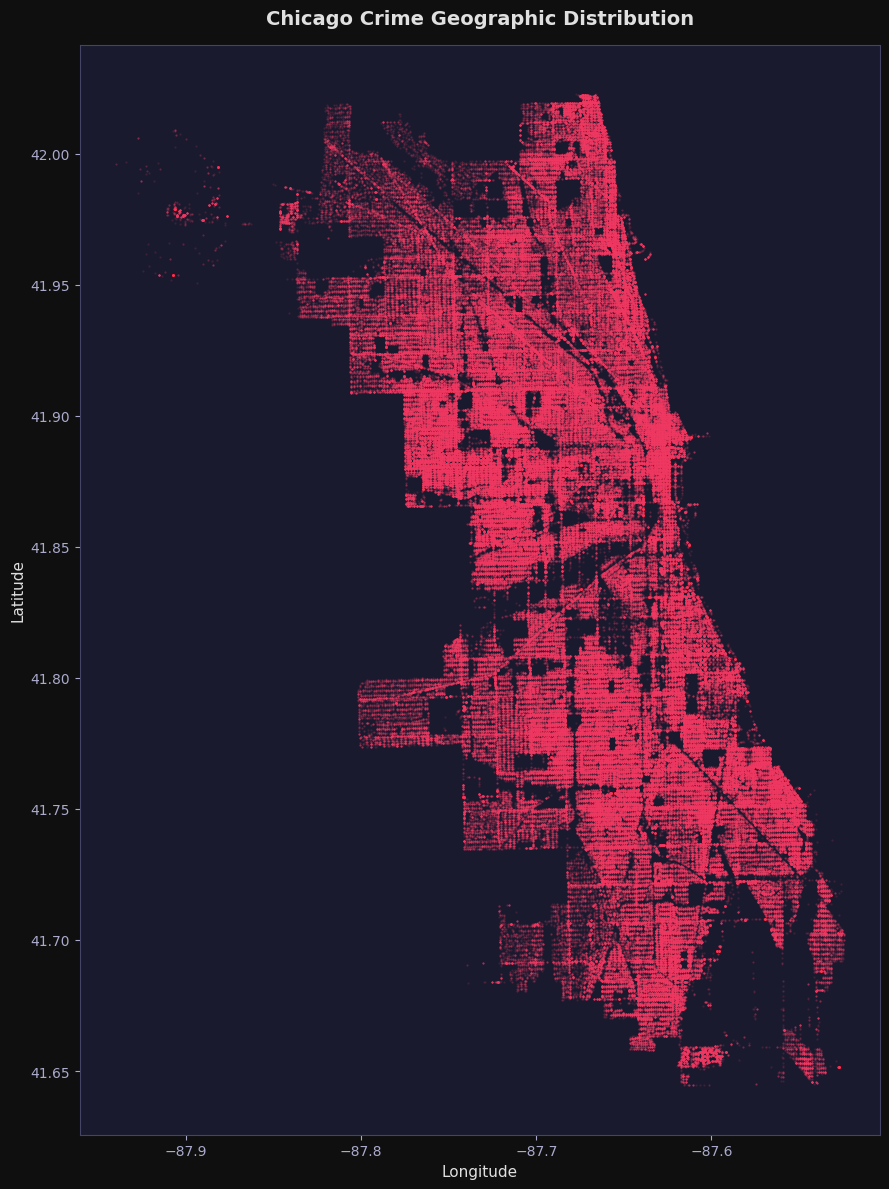

In [22]:
# --- Crime density scatter map ---
geo = df.dropna(subset=['latitude', 'longitude'])
geo = geo[(geo['latitude'] > 41.6) & (geo['latitude'] < 42.1)]

fig, ax = plt.subplots(figsize=(9, 12))
ax.scatter(
    geo['longitude'], geo['latitude'],
    s=0.3, alpha=0.15, c=ACCENT2, rasterized=True
)
ax.set_title('Chicago Crime Geographic Distribution', fontweight='bold', pad=15)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.show()

**Observation:** The scatter map reveals clear spatial clustering — crime is denser on the south and west sides of the city, consistent with known socioeconomic patterns in Chicago. The north lakefront corridor shows significantly lower density.

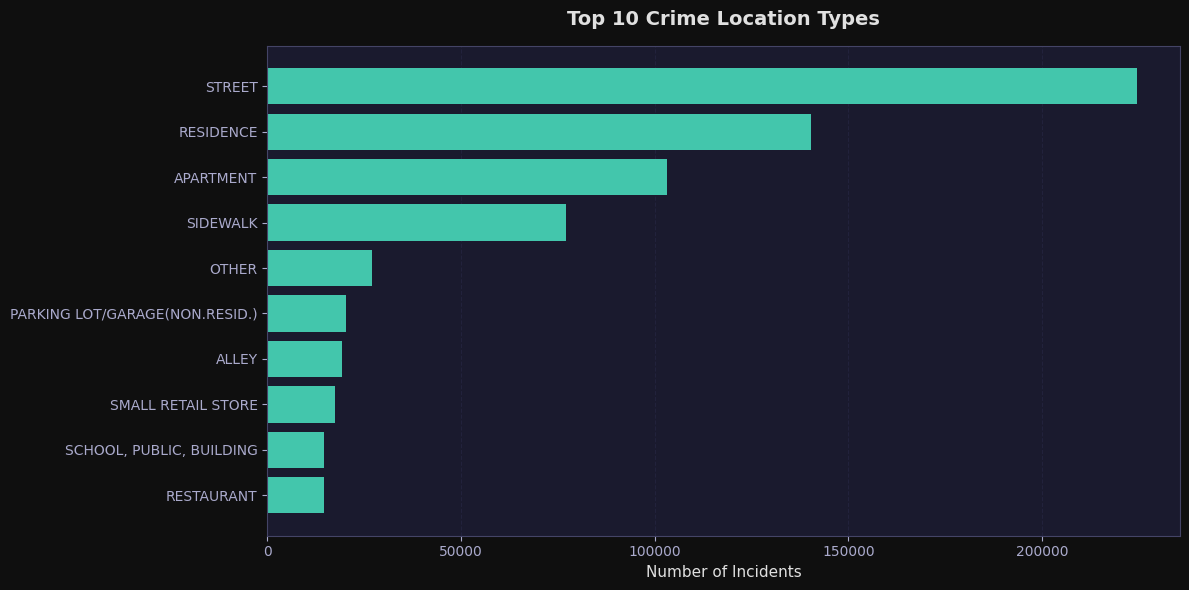

In [23]:
# --- Top 10 location descriptions ---
top_locations = df['location_description'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(top_locations.index[::-1], top_locations.values[::-1], color=ACCENT3, edgecolor='none')
ax.set_title('Top 10 Crime Location Types', fontweight='bold', pad=15)
ax.set_xlabel('Number of Incidents')
ax.grid(axis='x')
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

**Observation:** Streets and sidewalks are the most common crime locations, followed by residences and apartments. This split between public outdoor spaces and private residences has implications for crime prevention strategy.

## 7. Bivariate & Multivariate Analysis

Bivariate analysis examines relationships between two or more variables. Here we focus on factors associated with arrest outcomes — crime type, time trends, domestic status — and cross-tab patterns between crime type and hour of day.

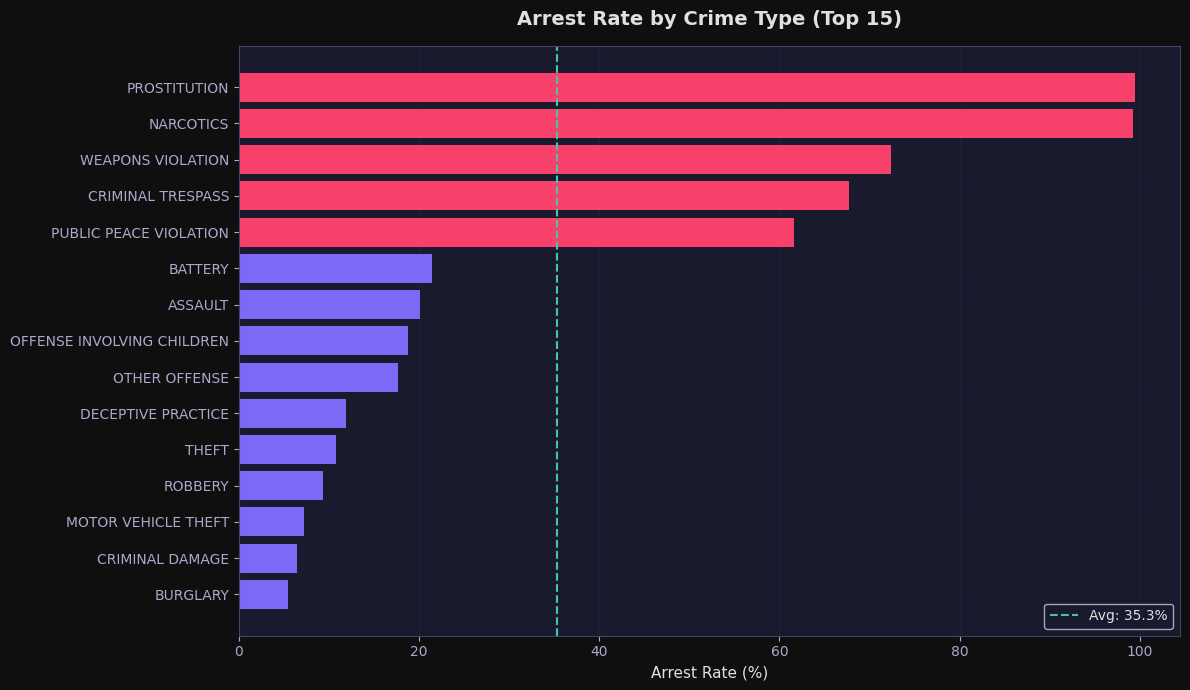

In [24]:
# --- Arrest rate by top 15 crime types ---
top15 = df['primary_type'].value_counts().head(15).index
arrest_by_type = (
    df[df['primary_type'].isin(top15)]
    .groupby('primary_type')['arrest']
    .mean()
    .sort_values()
)

fig, ax = plt.subplots(figsize=(12, 7))
colors = [ACCENT2 if v > 0.3 else ACCENT for v in arrest_by_type.values]
ax.barh(arrest_by_type.index, arrest_by_type.values * 100, color=colors, edgecolor='none')
ax.axvline(arrest_by_type.mean() * 100, color=ACCENT3, linestyle='--', linewidth=1.5, label=f'Avg: {arrest_by_type.mean()*100:.1f}%')
ax.set_title('Arrest Rate by Crime Type (Top 15)', fontweight='bold', pad=15)
ax.set_xlabel('Arrest Rate (%)')
ax.legend()
ax.grid(axis='x')
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

**Observation:** Arrest rates vary dramatically by crime type. Narcotics and weapons violations have the highest arrest rates — likely because these are often proactive enforcement (police find the crime rather than respond to it). Theft and burglary have among the lowest arrest rates, reflecting how hard property crimes are to clear. The average line helps contextualize which types are above or below baseline.

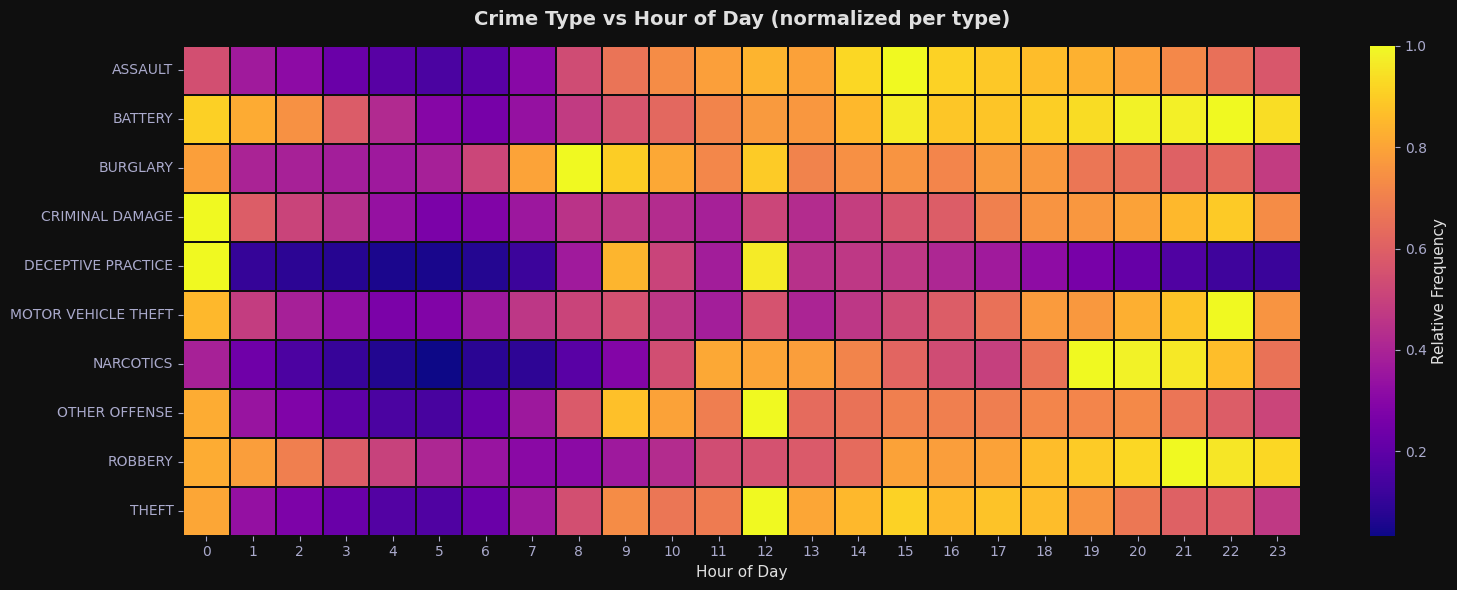

In [25]:
# --- Heatmap: crime type vs hour of day ---
top10_types = df['primary_type'].value_counts().head(10).index
heat_data = (
    df[df['primary_type'].isin(top10_types)]
    .groupby(['primary_type', 'hour'])
    .size()
    .unstack(fill_value=0)
)
# Normalize each row
heat_norm = heat_data.div(heat_data.max(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(
    heat_norm,
    cmap='plasma',
    ax=ax,
    linewidths=0.3,
    linecolor='#0f0f0f',
    cbar_kws={'label': 'Relative Frequency'}
)
ax.set_title('Crime Type vs Hour of Day (normalized per type)', fontweight='bold', pad=15)
ax.set_xlabel('Hour of Day')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

**Observation:** The heatmap reveals distinct time-of-day signatures by crime type. Narcotics incidents spike in afternoon hours. Theft peaks during business hours. Battery and assault show evening concentration. These patterns suggest that different crime types have fundamentally different behavioral drivers.

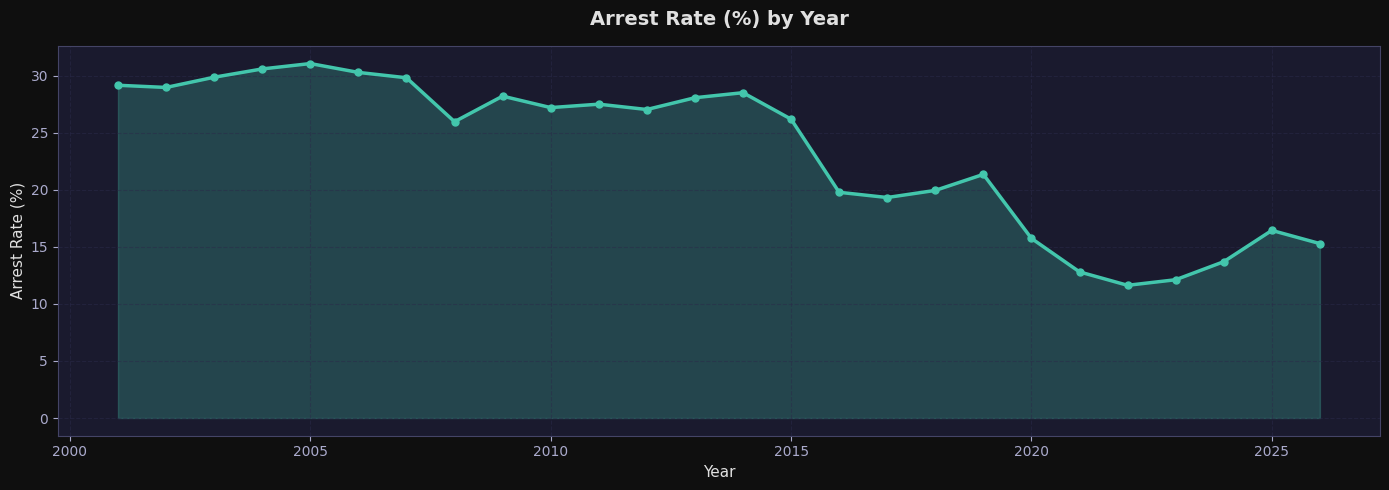

In [26]:
# --- Arrest rate over the years ---
arrest_by_year = df.groupby('year')['arrest'].mean() * 100

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(arrest_by_year.index, arrest_by_year.values, alpha=0.25, color=ACCENT3)
ax.plot(arrest_by_year.index, arrest_by_year.values, color=ACCENT3, linewidth=2.5, marker='o', markersize=5)
ax.set_title('Arrest Rate (%) by Year', fontweight='bold', pad=15)
ax.set_xlabel('Year')
ax.set_ylabel('Arrest Rate (%)')
ax.grid(True)
plt.tight_layout()
plt.show()

**Observation:** Arrest rates have shifted over time — worth noting whether the trend is improving or declining in recent years. A structural drop at a particular year could reflect a policy change, reporting change, or shift in the types of crimes being committed.

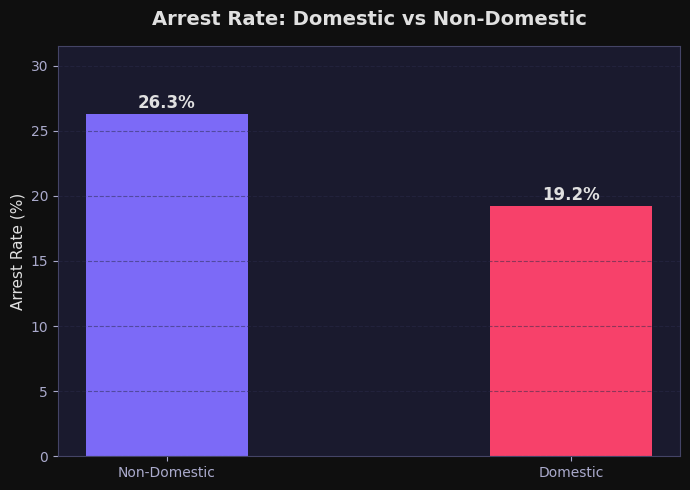

In [27]:
# --- Domestic crimes: arrest rate comparison ---
domestic_arrest = df.groupby('domestic')['arrest'].mean() * 100
labels = ['Non-Domestic', 'Domestic']

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(labels, domestic_arrest.values, color=[ACCENT, ACCENT2], edgecolor='none', width=0.4)
for bar, val in zip(bars, domestic_arrest.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', fontsize=12, fontweight='bold')
ax.set_title('Arrest Rate: Domestic vs Non-Domestic', fontweight='bold', pad=15)
ax.set_ylabel('Arrest Rate (%)')
ax.set_ylim(0, domestic_arrest.max() * 1.2)
ax.grid(axis='y')
plt.tight_layout()
plt.show()

**Observation:** Domestic incidents have a notably different arrest rate than non-domestic ones. This is a meaningful finding — it may reflect mandatory arrest policies for domestic violence in Illinois, or conversely, challenges in prosecution that reduce arrests despite reports.

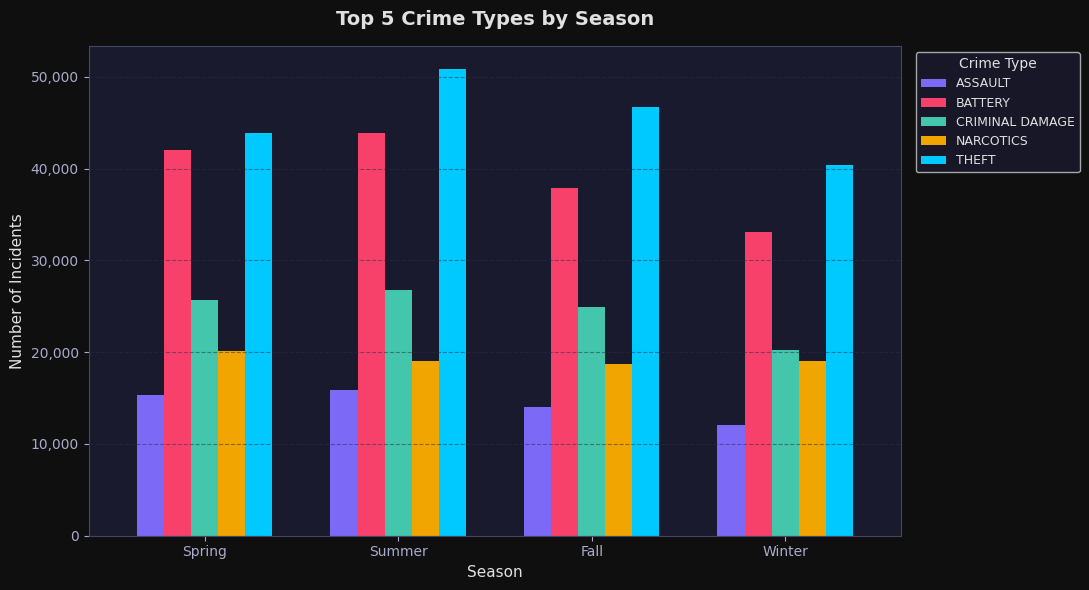

In [28]:
# --- Top crime types by season ---
top5 = df['primary_type'].value_counts().head(5).index
season_order = ['Spring', 'Summer', 'Fall', 'Winter']
season_crime = (
    df[df['primary_type'].isin(top5)]
    .groupby(['season', 'primary_type'])
    .size()
    .unstack(fill_value=0)
    .reindex(season_order)
)

colors_palette = [ACCENT, ACCENT2, ACCENT3, '#f0a500', '#00c9ff']
fig, ax = plt.subplots(figsize=(11, 6))
season_crime.plot(kind='bar', ax=ax, color=colors_palette, edgecolor='none', width=0.7)
ax.set_title('Top 5 Crime Types by Season', fontweight='bold', pad=15)
ax.set_xlabel('Season')
ax.set_ylabel('Number of Incidents')
ax.set_xticklabels(season_order, rotation=0)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(title='Crime Type', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.grid(axis='y')
plt.tight_layout()
plt.show()

**Observation:** Theft and battery follow a clear seasonal pattern, peaking in summer. The seasonal signal is strongest for street-level crimes and weakest for crimes that occur indoors (e.g., deceptive practice). This aligns with the routine activity theory — more people outside in summer means more opportunity.

## 10. Machine Learning — Arrest Prediction Model
Can we predict whether an arrest will be made based on what the crime was, when it happened, and where?

This section builds a Random Forest classifier to answer that question and uses feature importance scores to identify which factors most influence arrest outcomes.

**Features used:**
- `primary_type` — what kind of crime it was
- `hour`, `month`, `day_of_week`, `season` — when it happened
- `district`, `beat` — where it happened
- `domestic` — whether it was a domestic incident
- `location_description` — the type of location (street, residence, etc.)

**Target:** `arrest` (1 = arrest made, 0 = no arrest)

In [29]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report

features = ['primary_type', 'hour', 'month', 'day_of_week',
            'district', 'domestic', 'season', 'location_description']

df_ml = df[features + ['arrest']].dropna().copy()

for col in ['primary_type', 'day_of_week', 'season', 'location_description']:
    df_ml[col] = LabelEncoder().fit_transform(df_ml[col])

X = df_ml.drop(columns='arrest')
y = df_ml['arrest'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

print(classification_report(y_test, model.predict(X_test)))

              precision    recall  f1-score   support

           0       0.87      0.95      0.91    128614
           1       0.79      0.59      0.68     43109

    accuracy                           0.86    171723
   macro avg       0.83      0.77      0.79    171723
weighted avg       0.85      0.86      0.85    171723



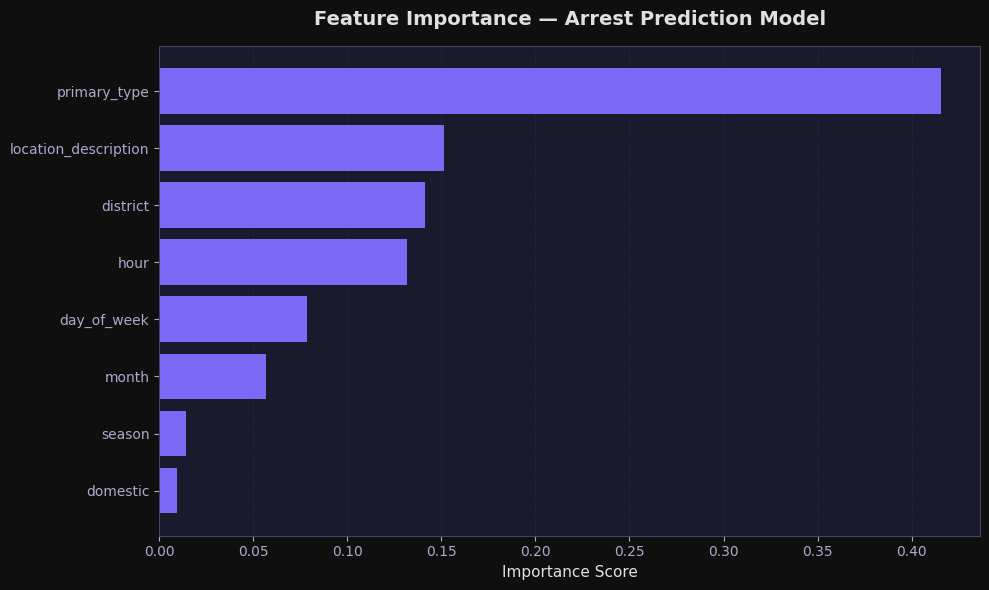

In [30]:
# --- Feature importance chart ---
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(importances.index, importances.values, color=ACCENT, edgecolor='none')
ax.set_title('Feature Importance — Arrest Prediction Model', fontweight='bold', pad=15)
ax.set_xlabel('Importance Score')
ax.grid(axis='x')
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

In [31]:
# --- Export feature importances for Power BI ---
importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

importance_df.to_csv('feature_importance.csv', index=False)
print('Saved feature_importance.csv ✅')
importance_df

Saved feature_importance.csv ✅


,feature,importance
0,primary_type,0.415579
1,location_description,0.151404
2,district,0.141490
3,hour,0.131964
4,day_of_week,0.078530
5,month,0.056941
6,season,0.014439
7,domestic,0.009653


**Findings:**

The model reached **86% overall accuracy** on data it had never seen before, which is a strong result for a real-world crime dataset.

Breaking down the classification report:

- **No arrest (0):** Precision 0.87, Recall 0.95 — the model is very good at identifying cases that won't lead to an arrest
- **Arrest made (1):** Precision 0.79, Recall 0.59 — it struggles more here, catching only 59% of actual arrests. This is expected since arrests are the minority class (about 25% of the data)

The feature importance chart tells a clear story:

- **`primary_type` dominates at ~0.42** — crime category is by far the strongest predictor of whether an arrest gets made. This lines up with what the EDA showed: narcotics and weapons crimes get arrested at much higher rates than theft or criminal damage
- **`location_description` and `district` are roughly equal at ~0.15** — where the crime happened matters more than expected, suggesting certain locations and districts have meaningfully different enforcement patterns
- **`hour` (~0.13) and `day_of_week` (~0.08)** contribute real signal — time of day influences arrest likelihood, likely because of staffing levels and what types of crimes happen at different hours
- **`domestic` scored near zero (~0.02)** — surprisingly low given how distinct domestic incidents looked in the EDA. The model may not be weighting it heavily because domestic vs. non-domestic correlates strongly with crime type, which already has a much stronger signal

Overall: arrest likelihood in Chicago is driven primarily by *what kind of crime it is*, with location and time adding meaningful but secondary influence.

## 8. Summary Statistics & Key Findings

The cell below prints a quick-reference stats block. The written findings follow.

In [32]:
# --- Key stats summary ---
print('=' * 50)
print('📊  CHICAGO CRIME — KEY STATS SUMMARY')
print('=' * 50)
print(f"Total records:          {len(df):,}")
print(f"Year range:             {df['year'].min()} – {df['year'].max()}")
print(f"Unique crime types:     {df['primary_type'].nunique()}")
print(f"Unique districts:       {df['district'].nunique()}")
print(f"Overall arrest rate:    {df['arrest'].mean()*100:.1f}%")
print(f"Domestic crime rate:    {df['domestic'].mean()*100:.1f}%")
print(f"Most common crime:      {df['primary_type'].value_counts().idxmax()}")
print(f"Peak crime hour:        {df['hour'].value_counts().idxmax()}:00")
print(f"Peak crime month:       {df['month_name'].value_counts().idxmax()}")
print(f"Highest crime district: {df['district'].value_counts().idxmax()}")
print('=' * 50)

📊  CHICAGO CRIME — KEY STATS SUMMARY
Total records:          858,614
Year range:             2001 – 2026
Unique crime types:     33
Unique districts:       23
Overall arrest rate:    25.0%
Domestic crime rate:    17.3%
Most common crime:      THEFT
Peak crime hour:        0:00
Peak crime month:       Jul
Highest crime district: 8


## 9. Findings & Analytical Conclusions

### What the data shows

**Crime volume is declining long-term.** After peaking in the mid-2000s, total incident counts have trended down, which is a positive finding, though the rate of decline has slowed in recent years.

**Theft dominates the crime landscape.** It is the most frequent crime type by a large margin, yet has one of the lowest arrest rates. This gap between how often it happens and how rarely it gets solved is one of the most important takeaways from the dataset.

**Time patterns are strong and consistent.** Crime peaks in summer months, on evenings and midnight, and is relatively stable across weekdays with a slight Friday/Saturday uptick. These patterns are stable enough to support resource scheduling decisions.

**Geography matters.** A small number of districts account for a disproportionate share of incidents. The spatial scatter map confirms the south and west side concentration that aligns with broader socioeconomic research on Chicago.

**Arrest rates vary dramatically by crime type.** Narcotics and weapons charges get solved at high rates because police are actively looking for them, while property crimes like theft and burglary rarely lead to an arrest. This means clearance rates can be misleading — they reflect how enforceable a crime is, not necessarily how serious it is.

**The arrest prediction model confirmed what the EDA suggested.** With 86% accuracy, the Random Forest model showed that crime type is by far the strongest predictor of whether an arrest gets made (~0.42 importance score), followed by location and district (~0.15 each), then time of day (~0.13). Whether the incident was domestic had surprisingly little independent influence once crime type was already accounted for.

### Questions for further investigation

- Are certain crime types driving the long-term decline, or is it broad-based?
- Do arrest rates differ significantly by district, suggesting uneven enforcement across the city?
- How did the 2020 pandemic affect crime composition, not just total volume?
- Can the model's recall on actual arrests (currently 59%) be improved with more features or a different algorithm?

### Dashboard implications

The most impactful visualizations for the final dashboard will be: (1) year-over-year crime trend, (2) arrest rate by crime type, (3) time-of-day heatmap, (4) district-level geographic breakdown, and (5) feature importance chart from the arrest prediction model. These five views capture the full story of the dataset — from raw patterns to a data-driven explanation of what drives outcomes.